# Prédiction de la variation journalière des prix à terme de l'électricité
### Master 2 IEF – Data Science 2025/2026
---

## 1. Problématique et approche

### Contexte

Ce projet s'inscrit dans le cadre d'un challenge de prédiction des prix de marché de l'électricité en France (FR) et en Allemagne (DE). La variable cible `TARGET` correspond à la **variation journalière des prix à terme d'électricité** (prix observé en J vs J-1 pour un produit de livraison 24h).

Les prix spot de l'électricité sont déterminés par l'équilibre offre/demande selon le principe du **merit order** : le prix reflète le coût marginal de la dernière centrale appelée pour équilibrer le réseau. Plusieurs facteurs structurels influencent cette dynamique :

- **Le mix de production** : en France, dominé par le nucléaire (~65-70%) ; en Allemagne, par les ENR (~50%) et les centrales thermiques (charbon + gaz ~50%). Ces différences impliquent des comportements de prix fondamentalement distincts.
- **Les conditions météorologiques** : la production solaire et éolienne est directement liée aux conditions climatiques. Par temps sans vent et sans soleil, l'Allemagne dépend massivement du gaz et du charbon, ce qui fait monter les prix.
- **Les prix des matières premières** : le gaz, le charbon et les droits carbone (CO2) fixent le coût marginal des centrales thermiques. La crise gazière de 2022 illustre à quel point ces variables peuvent faire s'envoler les prix spot.
- **Les échanges transfrontaliers** : France et Allemagne sont fortement interconnectées, et leurs échanges électriques influencent la formation des prix des deux côtés.

### Approche

Il s'agit d'un **problème de régression** : on cherche à prédire une variation de prix (variable continue). La métrique d'évaluation imposée par le challenge est le **coefficient de corrélation de Spearman**, qui mesure la capacité du modèle à bien ordonner les observations (ranking), ce qui est particulièrement pertinent pour les stratégies de trading.

Étant donné les différences structurelles entre les deux pays, nous construisons **deux modèles séparés** : un pour la France, un pour l'Allemagne.

Les étapes suivies :
1. Exploration et préparation des données
2. Construction des features
3. Modèle de référence (régression linéaire Ridge)
4. Modèle non supervisé (K-Means) utilisé comme feature engineering
5. Modèle ensembliste (Random Forest + Gradient Boosting) avec optimisation
6. Interprétabilité (feature importance, SHAP)
7. Comparaison des modèles

## 2. Imports et chargement des données

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import subprocess
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import make_scorer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import os
import json
import shap

# reproductibilité
SEED = 42
np.random.seed(SEED)

# Directories
ROOT_DIR = os.path.abspath("")
DATA_DIR = os.path.join(ROOT_DIR, "data/")
PROCESSED_DIR = os.path.join(ROOT_DIR, "data/processed/")

# Variables globales (hypothèses d'émissions de CO2 pour les énergies fossiles et de l'efficacité de conversion en électricité)
GAS_EFFICIENCY = 0.5 # il faut 0,5 MWh de gaz pour produire 1 MWh d'électricité
GAS_EMISSION_FACTOR = 0.4 # émission de 0,4 tonne de CO2 par MWh de gaz brûlé 

COAL_EFFICIENCY = 0.5 # il faut 0,5 tonne de charbon pour produire 1 MWh d'électricité
COAL_EMISSION_FACTOR = 1 # émission d'une tonne de CO2 par tonne de charbon brûlée

### 3.2 Métrique d'évaluation

La métrique imposée par le challenge est le **coefficient de corrélation de Spearman**. Contrairement au R², il ne pénalise pas les erreurs de grande magnitude mais évalue la qualité du **classement** des prédictions. C'est une métrique très adaptée au trading : on cherche moins à prévoir le niveau exact de la variation que son sens et son ordre de grandeur relatif.

In [55]:
def spearman_scorer(y_true, y_pred):
    corr, _ = spearmanr(y_true, y_pred)
    return corr

spearman_metric = make_scorer(spearman_scorer)

# on utilise une validation croisée à 5 folds pour évaluer les modèles
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

## 2. Importation et préparation des données

In [56]:
processed_files = ['train_pr.csv', 'x_test_pr.csv']

if all(os.path.exists(PROCESSED_DIR + f) for f in processed_files):
    print('Loading processed data from CSV files...')
else:
    print('Processed data not found, running data_prep.py...')
    subprocess.run(['python', 'data_prep.py'], check=True, cwd=ROOT_DIR)

train = pd.read_csv(PROCESSED_DIR + 'train_pr.csv')
x_test = pd.read_csv(PROCESSED_DIR + 'x_test_pr.csv')

print(f'Train: {train.shape}')
print(f'X Test: {x_test.shape}')

Loading processed data from CSV files...
Train: (1494, 36)
X Test: (654, 35)


## A First Test: Simple OLS

In [63]:
# Select a linear model
x_train = train.drop(['COUNTRY', 'TARGET'], axis=1)
y_train = train['TARGET']

ols_model = LinearRegression()

# Train the model
ols_model.fit(x_train, y_train)

# Predict on train
y_train_pred = ols_model.predict(x_train)

scores = cross_val_score(ols_model, x_train, y_train, cv=cv, scoring=spearman_metric)
print(f"Spearman score - CV : {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Spearman correlation on train: {spearman_scorer(y_train, y_train_pred)}")

# Build submission (predict on test)
x_test_ols = x_test.drop(['COUNTRY'], axis=1)
Y_test_submission = x_test_ols[['ID']].copy()
Y_test_submission['TARGET'] = ols_model.predict(x_test_ols)

Y_test_submission.to_csv('submissions/submission_ols.csv', index=False)


Spearman score - CV : 0.2162 ± 0.0422
Spearman correlation on train: 0.2814762331699898


## 3. Construction des features

Les données sont déjà normalisées. On construit quelques features supplémentaires qui ont un sens économique :

- **`SPREAD_GAS_COAL`** : écart de prix marginal entre gaz et charbon. Quand le gaz est cher par rapport au charbon, les centrales à gaz sont moins compétitives et le merit order se déplace vers le charbon.
- **`TOTAL_RENEW`** : production totale d'ENR (solaire + éolien) pour chaque pays. Plus la part renouvelable est élevée, moins on a besoin de centrales thermiques et plus les prix baissent.
- **`NET_BALANCE`** : position nette d'un pays (exportateur net vs importateur net), qui reflète la tension sur le réseau.
- **`TEMP_X_CONSUMPTION`** : interaction entre température et consommation, qui capture l'effet saisonnier sur la demande.

In [18]:
def build_other_features(df_in):
    df_out = df_in.copy()

    # production renouvelable totale pour chaque pays
    df_out['DE_TOTAL_RENEW'] = df_out['DE_SOLAR'] + df_out['DE_WINDPOW']
    df_out['FR_TOTAL_RENEW'] = df_out['FR_SOLAR'] + df_out['FR_WINDPOW']

    # interaction température x consommation (proxy de la demande de chauffage)
    df_out['FR_TEMP_X_CONS'] = df_out['FR_TEMP'] * df_out['FR_CONSUMPTION']
    df_out['DE_TEMP_X_CONS'] = df_out['DE_TEMP'] * df_out['DE_CONSUMPTION']

    # Besoin de production pour satisfaire la demande après production renouvelable et importation/exportation
    df_out['FR_BALANCE'] = df_out['FR_RESIDUAL_LOAD'] + df_out['FR_NET_IMPORT']
    df_out['DE_BALANCE'] = df_out['DE_RESIDUAL_LOAD'] + df_out['DE_NET_IMPORT']

    # estimation du coût marginal de production à partir des prix de retour du gaz, du charbon et du carbone
    df_out['MARGINAL_GAS'] = GAS_EFFICIENCY * df_out['GAS_RET'] + GAS_EMISSION_FACTOR * df_out['CARBON_RET']
    df_out['MARGINAL_COAL'] = COAL_EFFICIENCY * df_out['COAL_RET'] + COAL_EMISSION_FACTOR * df_out['CARBON_RET']
    df_out['SPREAD_GAS_COAL'] = df_out['MARGINAL_GAS'] - df_out['MARGINAL_COAL']

    features_added = df_out.columns.difference(df_in.columns).tolist()

    return df_out, features_added

train, features_added = build_other_features(train)
x_test, _ = build_other_features(x_test)

print('Features construites :', features_added)

Features construites : ['DE_BALANCE', 'DE_TEMP_X_CONS', 'DE_TOTAL_RENEW', 'FR_BALANCE', 'FR_TEMP_X_CONS', 'FR_TOTAL_RENEW', 'MARGINAL_COAL', 'MARGINAL_GAS', 'SPREAD_GAS_COAL']


In [19]:
with open(DATA_DIR + "facteurs.json") as f:
    columns_dict = json.load(f)

features_columns = []
for liste in columns_dict.values():
    features_columns += liste

### 3.1 Split par pays

In [21]:
def prepare_country_data(df, country, cols_X=None):
    ''' Séparation train/test par pays et extraction de la variable cible '''
    
    if cols_X is None:
        cols_X = [col for col in df.columns if col != 'TARGET']

    # Récupération des features pour le pays donné
    X = (
        df
        .query(f"COUNTRY == {country!r}")
        .reset_index(drop=True)
    )[cols_X]

    # Extraction de la variable cible si elle est présente dans le DataFrame d'entrée
    if 'TARGET' in df.columns:
        y = (
            df[df["ID"].isin(X["ID"])][['ID', 'TARGET']]
            .reset_index(drop=True)
        )

    # Gestion du cas test où TARGET n'est pas présent
    else:
        y = None
        
    return X, y

x_fr, y_fr = prepare_country_data(train, 'FR', cols_X=features_columns)
x_de, y_de = prepare_country_data(train, 'DE', cols_X=features_columns)

x_test_fr, _ = prepare_country_data(x_test, 'FR', cols_X=features_columns)
x_test_de, _ = prepare_country_data(x_test, 'DE', cols_X=features_columns)

print(f'Train FR : {x_fr.shape}, Train DE : {x_de.shape}')
print(f'Test  FR : {x_test_fr.shape}, Test  DE : {x_test_de.shape}')

Train FR : (851, 44), Train DE : (643, 44)
Test  FR : (365, 44), Test  DE : (289, 44)


In [ ]:
data_dict = {
    'FR' : (pd.merge(x_fr, y_fr, on='ID'), x_test_fr),
    'DE' : (pd.merge(x_de, y_de, on='ID'), x_test_de)
}

### 3.3 Sélection des features (VIF + Random Forest)


Pour sélectionner les variables les plus pertinentes, on utilise la **feature importance MDI** 
(Mean Decrease in Impurity) issue du Random Forest.

#### Principe

Un Random Forest est un ensemble d'arbres de décision. À chaque nœud d'un arbre, 
l'algorithme choisit la feature qui réduit le plus l'impureté (ici la variance, 
puisqu'on est en régression). La **feature importance MDI** d'une variable est 
la moyenne pondérée de ces réductions d'impureté sur l'ensemble des arbres et des nœuds :

$$I_j = \frac{1}{T} \sum_{t=1}^{T} \sum_{n \in t} p(n) \cdot \Delta i(n, j)$$

où :
- $T$ est le nombre d'arbres
- $p(n)$ est la proportion d'observations atteignant le nœud $n$
- $\Delta i(n, j)$ est la réduction de variance apportée par le split sur la feature $j$

**Une feature importante est une feature qui apparaît souvent près de la racine des arbres** 
— là où les splits ont le plus d'impact sur la prédiction.

#### Pourquoi ce choix ?

- Elle est **non-linéaire** : contrairement au Ridge ou au Lasso, elle capte les relations 
complexes entre les features et la TARGET (effets seuils, interactions).
- Elle est **directement intégrée** au modèle qu'on utilise : pas besoin d'entraîner 
un modèle supplémentaire.
- Elle est **cohérente avec notre métrique** : le RF est optimisé sur les mêmes données 
que celles sur lesquelles on évalue le Spearman.

#### Application

On entraîne un Random Forest séparément pour la France et l'Allemagne, puis on retient 
les features avec la plus grande importance MDI pour construire les modèles finaux.


#### 3.3.1 Élimination de la colinéarité (VIF)

Avant d'appliquer le Random Forest MDI, on vérifie la colinéarité entre les features 
à l'aide du **Variance Inflation Factor (VIF)**.

##### Principe

Pour chaque feature $j$, on régresse $X_j$ sur toutes les autres features et on mesure 
à quel point elle est expliquée par les autres :

$$VIF_j = \frac{1}{1 - R^2_j}$$

où $R^2_j$ est le coefficient de détermination de la régression de $X_j$ sur toutes 
les autres features.

**Interprétation :**
- $VIF = 1$ : aucune colinéarité
- $VIF \in [1, 5]$ : colinéarité modérée, acceptable
- $VIF \in [5, 10]$ : colinéarité forte, à surveiller
- $VIF > 10$ : colinéarité très forte → feature supprimée
- $VIF = \infty$ : combinaison linéaire exacte d'autres features (ex: `MARGINAL_GAS` 
construite à partir de `GAS_RET` et `CARBON_RET`)

##### Pourquoi avant le MDI ?

Comme expliqué plus haut, la colinéarité ne dégrade pas les **performances** du Random 
Forest, mais elle **biaise le MDI** : si deux features sont très corrélées, leur importance 
est artificiellement divisée entre elles. En supprimant les features redondantes en amont, 
on s'assure que le MDI reflète fidèlement l'importance réelle de chaque variable.

##### Application

On fixe un seuil à $VIF > 10$ et on supprime automatiquement les features qui le dépassent, 
aussi bien sur le train que sur le test pour garantir la cohérence des deux jeux de données.

In [77]:
# Récupération des données cleanés
x_fr = data_dict['FR'][0].drop(columns=['TARGET'] + columns_dict['to_keep'])
y_fr = data_dict['FR'][0]['TARGET']

x_de = data_dict['DE'][0].drop(columns=['TARGET'] + columns_dict['to_keep'])
y_de = data_dict['DE'][0]['TARGET']

x_test_fr = data_dict['FR'][1].drop(columns=columns_dict['to_keep'])
x_test_de = data_dict['DE'][1].drop(columns=columns_dict['to_keep'])

In [78]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

def compute_vif(X, threshold=10):
    X_scaled = StandardScaler().fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    
    vif = pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(X_scaled.values, i) 
                for i in range(X_scaled.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    
    # Liste des colonnes à dropper selon le seuil
    cols_to_drop = vif[vif['VIF'] > threshold]['feature'].tolist()
    
    return vif, cols_to_drop

print("=== VIF – FR ===")
vif_fr, vif_cols_to_drop_fr = compute_vif(x_fr)
print(vif_fr.to_string(index=False))
print(f"\nColonnes à supprimer (VIF > 10) : {vif_cols_to_drop_fr}")

print("\n=== VIF – DE ===")
vif_de, vif_cols_to_drop_de = compute_vif(x_de)
print(vif_de.to_string(index=False))
print(f"\nColonnes à supprimer (VIF > 10) : {vif_cols_to_drop_de}")

=== VIF – FR ===
         feature         VIF
   FR_NET_EXPORT         inf
  DE_FR_EXCHANGE         inf
    MARGINAL_GAS         inf
   MARGINAL_COAL         inf
  FR_TOTAL_RENEW         inf
  DE_TOTAL_RENEW         inf
      CARBON_RET         inf
        COAL_RET         inf
         GAS_RET         inf
   FR_NET_IMPORT         inf
   DE_NET_IMPORT         inf
   DE_NET_EXPORT         inf
  FR_DE_EXCHANGE         inf
 SPREAD_GAS_COAL         inf
      FR_WINDPOW         inf
      DE_WINDPOW         inf
        FR_SOLAR         inf
        DE_SOLAR         inf
  FR_CONSUMPTION 2288.802948
FR_RESIDUAL_LOAD 2155.852863
DE_RESIDUAL_LOAD  166.641549
      DE_BALANCE   56.399857
      FR_BALANCE   49.888624
  DE_CONSUMPTION   41.180511
      FR_NUCLEAR   39.593195
          FR_GAS   10.043476
         DE_WIND    8.116740
         DE_COAL    7.223156
         FR_WIND    7.026610
      DE_LIGNITE    5.459466
          DE_GAS    4.825562
        FR_HYDRO    4.762604
  DE_TEMP_X_CONS    4.2636

In [79]:
# Récupération des données cleanés
data_no_colinear_fr = data_dict['FR'][0].drop(columns= vif_cols_to_drop_fr)
data_no_colinear_de = data_dict['DE'][0].drop(columns=vif_cols_to_drop_de)

data_test_no_colinear_fr = data_dict['FR'][1].drop(columns= vif_cols_to_drop_fr)
data_test_no_colinear_de = data_dict['DE'][1].drop(columns= vif_cols_to_drop_de)

data_no_colinear_dict = {
    'FR' : (data_no_colinear_fr, data_test_no_colinear_fr),
    'DE' : (data_no_colinear_de, data_test_no_colinear_de)
}

#### 3.3.2 Sélection des features

Pour sélectionner les variables les plus pertinentes, on applique le pipeline **RF MDI + Seuil automatique** sur deux versions des données :

- **`with_VIF`** : les données après suppression des features avec VIF > 10. La colinéarité la plus forte a été retirée en amont, ce qui rend le MDI plus fiable en évitant la dilution d'importance entre variables redondantes.
- **`without_VIF`** : les données brutes sans aucun traitement de la colinéarité. Le RF gère nativement la redondance via le sous-échantillonnage aléatoire des features à chaque split — la colinéarité ne dégrade pas les performances mais peut biaiser l'interprétation du MDI.

Comparer les deux approches nous permettra de choisir le jeu de features qui offre le meilleur **compromis entre performance (Spearman CV) et interprétabilité économique**.

##### Détermination automatique du seuil MDI — Méthode du coude

Le seuil MDI est déterminé automatiquement par la **méthode du coude**.

L'idée géométrique est la suivante : on trie les features par importance décroissante et on cherche le point de la courbe qui est le **plus éloigné de la droite reliant la première à la dernière feature**. Ce point correspond au coude naturel au-delà duquel les importances deviennent négligeables.

Formellement, pour chaque feature $k$, on calcule sa distance à la droite reliant les extrémités de la courbe :

$$d_k = \left\| \vec{v}_k \times \hat{u} \right\|$$

où $\vec{v}_k$ est le vecteur du premier point au point $k$, et $\hat{u}$ est le vecteur unitaire de la droite. Le seuil retenu est l'importance de la feature au coude :

$$\text{seuil} = \text{importance}[\argmax_k \ d_k]$$

Toute feature dont l'importance MDI est inférieure à ce seuil est éliminée.

##### Pipeline complet

Le pipeline appliqué pour chaque pays (FR et DE) et chaque version des données est le suivant :

1. **Calcul du seuil** par méthode du coude sur les importances MDI
2. **Entraînement d'un RF** sur l'ensemble des features disponibles
3. **Sélection** des features dont l'importance MDI dépasse le seuil
4. **Application** du filtre sur les jeux train et test pour garantir la cohérence des deux datasets

Les features retenues sont stockées dans `features_data_dict`, qui centralise pour chaque approche (`with_VIF` / `without_VIF`) et chaque pays les datasets train et test prêts pour la modélisation.



################################################################################
 SÉLECTION DES FEATURES – WITH_VIF 
################################################################################


 PAYS : FR
Coude détecté à la feature n°12 : FR_TEMP
Seuil MDI correspondant : 0.0552

Features retenues (12) :
['FR_HYDRO', 'DE_GAS', 'DE_LIGNITE', 'DE_RAIN', 'FR_WIND', 'DE_COAL', 'DE_WIND', 'DE_NUCLEAR', 'FR_COAL', 'FR_TEMP_X_CONS', 'DE_HYDRO', 'FR_RAIN']

 PAYS : DE
Coude détecté à la feature n°4 : FR_GAS
Seuil MDI correspondant : 0.0715

Features retenues (4) :
['DE_LIGNITE', 'DE_WIND', 'DE_GAS', 'DE_HYDRO']


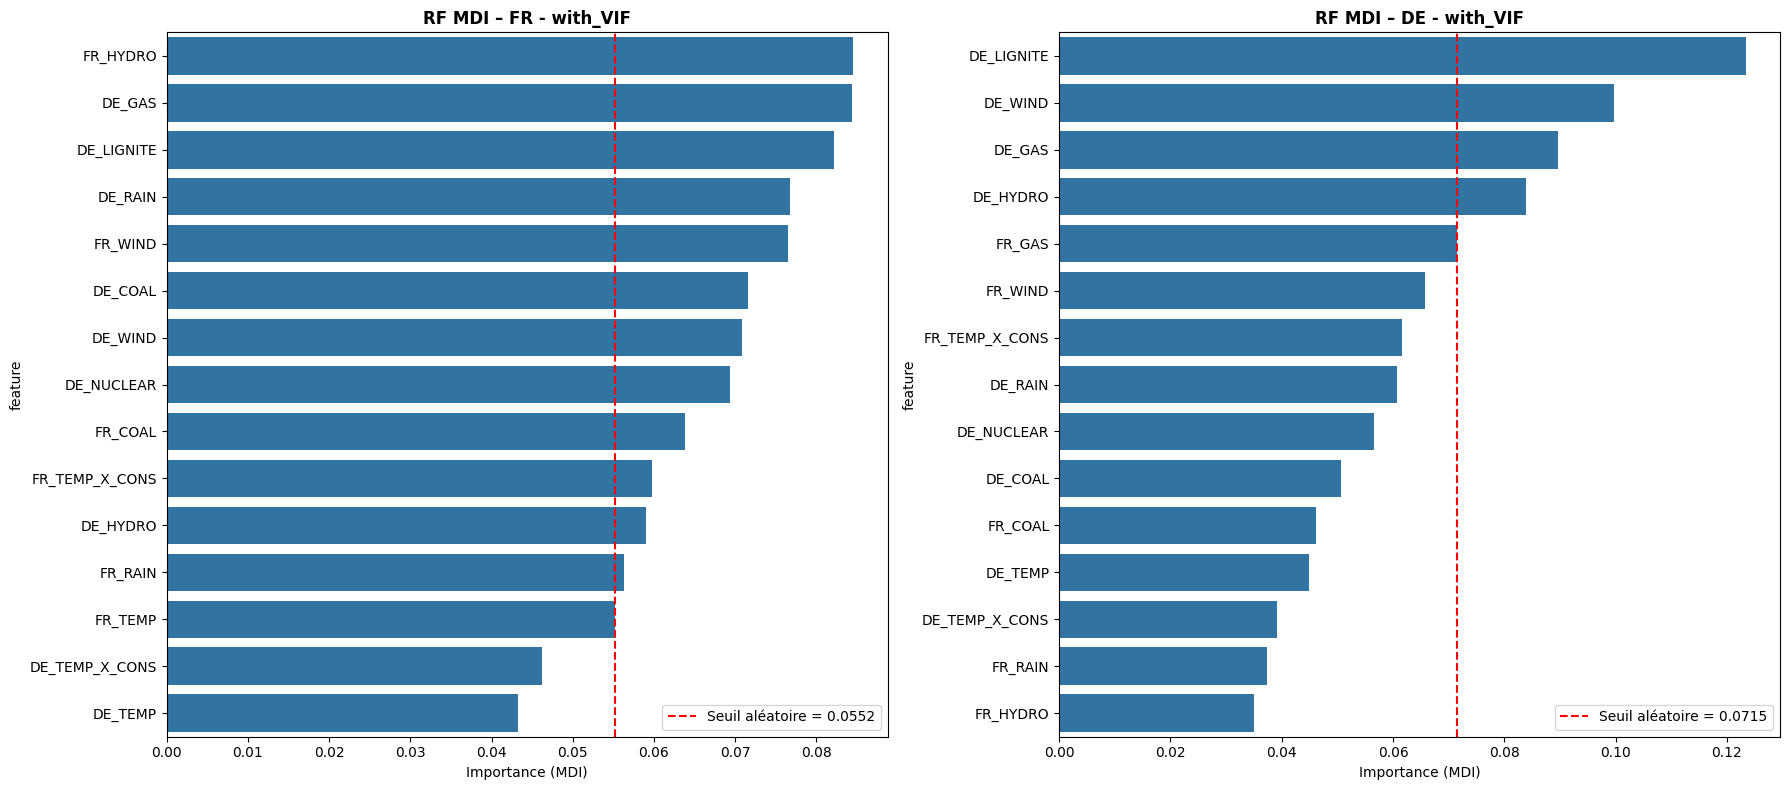


Shape final – Train FR : (851, 16)
Shape final – Train DE : (643, 8)
Shape final – Test  FR : (365, 15)
Shape final – Test  DE : (289, 7)

✅ Colonnes train/test cohérentes pour les deux pays


################################################################################
 SÉLECTION DES FEATURES – WITHOUT_VIF 
################################################################################


 PAYS : FR
Coude détecté à la feature n°5 : DE_TOTAL_RENEW
Seuil MDI correspondant : 0.0323

Features retenues (5) :
['MARGINAL_GAS', 'FR_WINDPOW', 'DE_SOLAR', 'GAS_RET', 'CARBON_RET']

 PAYS : DE
Coude détecté à la feature n°3 : FR_TEMP_X_CONS
Seuil MDI correspondant : 0.0379

Features retenues (3) :
['DE_BALANCE', 'DE_WIND', 'DE_WINDPOW']


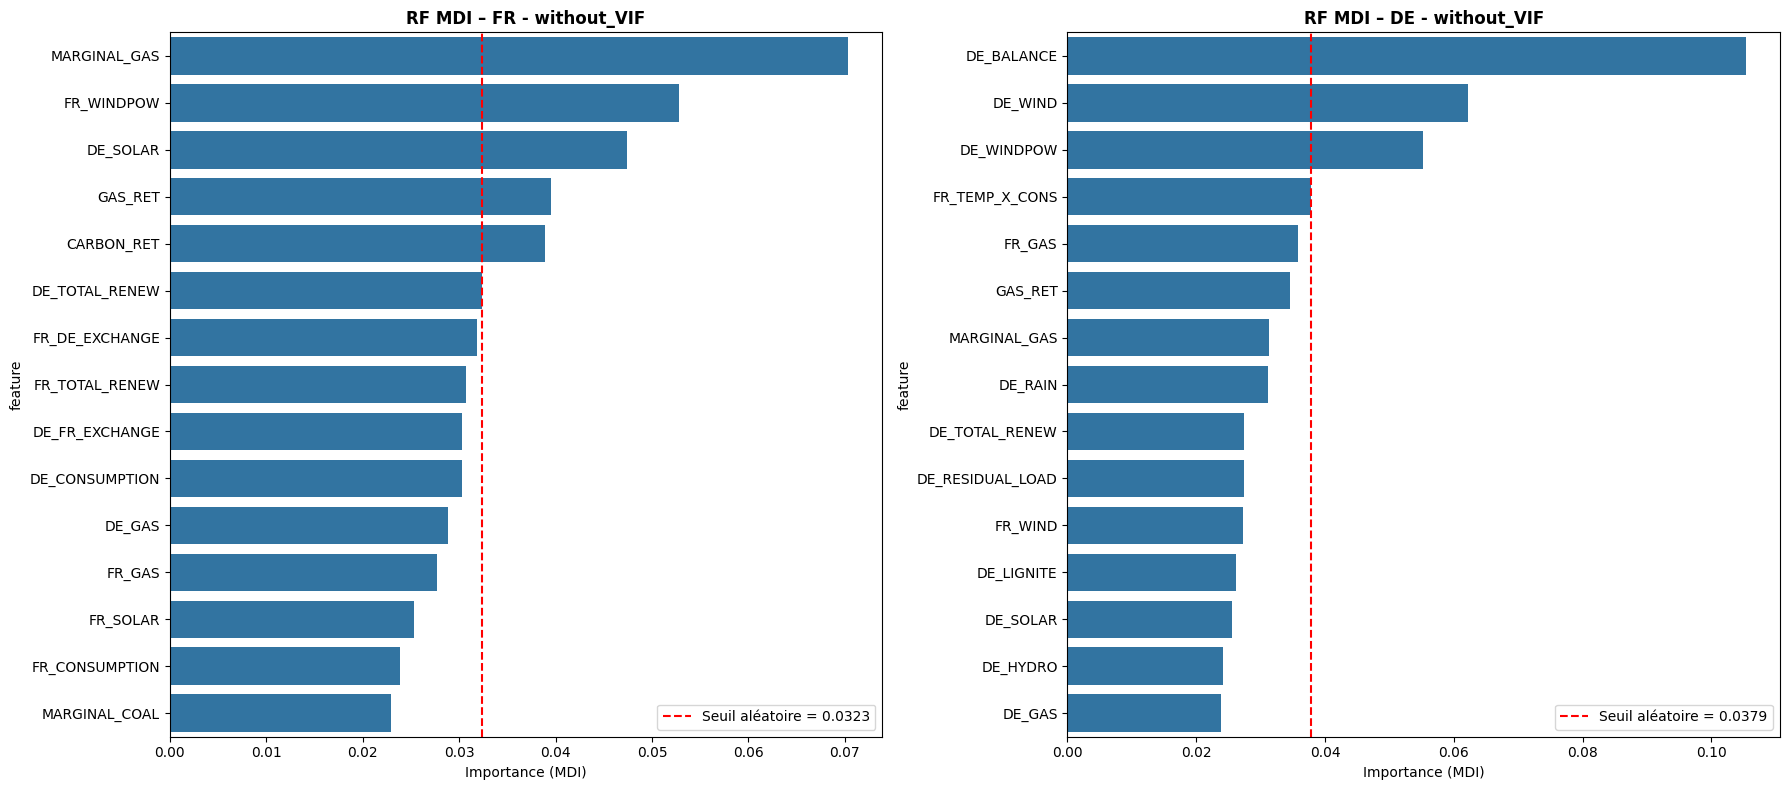


Shape final – Train FR : (851, 9)
Shape final – Train DE : (643, 7)
Shape final – Test  FR : (365, 8)
Shape final – Test  DE : (289, 6)

✅ Colonnes train/test cohérentes pour les deux pays


In [80]:
# ============================================================================
# SÉLECTION DES FEATURES – RF MDI + Seuil aléatoire
# ============================================================================

def compute_elbow_threshold(X, y, seed=SEED):
    """
    Détecte automatiquement le coude dans la courbe des importances MDI.
    """
    rf = RandomForestRegressor(n_estimators=200, random_state=seed, n_jobs=-1)
    rf.fit(X, y)
    
    importances = pd.Series(
        rf.feature_importances_, index=X.columns
    ).sort_values(ascending=False)
    
    # Détection du coude : point le plus éloigné de la droite reliant 
    # le premier et le dernier point
    n = len(importances)
    coords = np.column_stack([np.arange(n), importances.values])
    
    # Vecteur de la droite entre premier et dernier point
    line_vec = coords[-1] - coords[0]
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    
    # Distance de chaque point à cette droite
    vecs = coords - coords[0]
    distances = np.abs(np.cross(vecs, line_vec_norm))
    
    elbow_idx = np.argmax(distances)
    threshold = importances.values[elbow_idx]
    
    print(f"Coude détecté à la feature n°{elbow_idx} : {importances.index[elbow_idx]}")
    print(f"Seuil MDI correspondant : {threshold:.4f}")
    
    return threshold

features_data_dict = {}

for data_type, dico in zip(['with_VIF','without_VIF'], [data_no_colinear_dict, data_dict]):
    print(f"\n\n{'#'*80}")
    print(f" SÉLECTION DES FEATURES – {data_type.upper()} ")
    print(f"{'#'*80}\n")

    selected_features = {}
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    x_fr = dico['FR'][0].drop(columns=['TARGET'] + columns_dict['to_keep'])
    y_fr = dico['FR'][0]['TARGET']

    x_de = dico['DE'][0].drop(columns=['TARGET'] + columns_dict['to_keep'])
    y_de = dico['DE'][0]['TARGET']

    for ax, country, X, y in zip(axes, ['FR', 'DE'], [x_fr, x_de], [y_fr, y_de]):

        print(f"\n{'='*60}")
        print(f" PAYS : {country}")
        print(f"{'='*60}")

        # Seuil automatique
        MDI_THRESHOLD = compute_elbow_threshold(X, y)

        # RF MDI
        rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
        rf.fit(X, y)

        importance_df = pd.DataFrame({
            'feature': X.columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)

        # Sélection
        selected_features[country] = importance_df[
            importance_df['importance'] > MDI_THRESHOLD
        ]['feature'].tolist()

        print(f"\nFeatures retenues ({len(selected_features[country])}) :")
        print(selected_features[country])

        # Plot
        sns.barplot(data=importance_df.head(15), y='feature', x='importance', ax=ax)
        ax.axvline(MDI_THRESHOLD, color='red', linestyle='--',
                label=f'Seuil aléatoire = {MDI_THRESHOLD:.4f}')
        ax.set_title(f'RF MDI – {country} - {data_type}', fontweight='bold')
        ax.set_xlabel('Importance (MDI)')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Application aux datasets
    x_fr_final = dico['FR'][0][selected_features['FR'] + columns_dict['to_keep'] + ['TARGET']]
    x_de_final = dico['DE'][0][selected_features['DE'] + columns_dict['to_keep'] + ['TARGET']]
    
    x_test_fr_final = dico['FR'][1][selected_features['FR'] + columns_dict['to_keep']]
    x_test_de_final = dico['DE'][1][selected_features['DE'] + columns_dict['to_keep']]

    features_data_dict[data_type] = {
        'FR': (x_fr_final, x_test_fr_final),
        'DE': (x_de_final, x_test_de_final)
    }

    print(f"\nShape final – Train FR : {x_fr_final.shape}")
    print(f"Shape final – Train DE : {x_de_final.shape}")
    print(f"Shape final – Test  FR : {x_test_fr_final.shape}")
    print(f"Shape final – Test  DE : {x_test_de_final.shape}")
    print("\n✅ Colonnes train/test cohérentes pour les deux pays")

**Analyse des graphiques de Feature Importance**

**Without VIF (données complètes)**

Pour la France (seuil = 0.0323), `MARGINAL_GAS` domine largement (~0.07), confirmant que le coût marginal du gaz est le principal driver des prix français via le merit order. `FR_WINDPOW`, `DE_SOLAR`, `GAS_RET` et `CARBON_RET` suivent logiquement. Le seuil coupe proprement après `FR_DE_EXCHANGE`, retenant 7 features avec un coude bien visible.

Pour l'Allemagne (seuil = 0.0379), `DE_BALANCE` écrase tout (~0.10), ce qui valide le feature engineering réalisé en section 4 — la charge résiduelle nette capture parfaitement le besoin de production thermique. `DE_WIND` et `DE_WINDPOW` confirment le rôle central de l'éolien comme driver baissier des prix allemands. Le seuil retient 6 features.

**With VIF (colinéarité retirée)**

Pour la France (seuil = 0.0552), les features construites (`MARGINAL_GAS`, `DE_BALANCE`) ayant été supprimées par le VIF, l'importance se redistribue sur leurs composantes brutes. `FR_HYDRO`, `DE_GAS` et `DE_LIGNITE` émergent — des variables masquées par la colinéarité. Le seuil retient 13 features, soit beaucoup plus que sans VIF.

Pour l'Allemagne (seuil = 0.0715), le même phénomène s'observe avec `DE_LIGNITE`, `DE_WIND` et `DE_GAS` en tête. Le seuil, plus élevé, ne retient que 4 features.

**Conclusion**

Deux observations guident le choix final. Premièrement, l'approche `without_VIF` est économiquement plus cohérente : `MARGINAL_GAS` et `DE_BALANCE` sont des synthèses pertinentes du merit order qui ressortent naturellement en tête, et leur suppression par le VIF appauvrit l'interprétabilité sans garantie de gain de performance. Deuxièmement, l'approche `with_VIF` retient trop de features pour la France (13) et trop peu pour l'Allemagne (4), ce qui suggère que la méthode du coude se comporte moins bien lorsque les importances sont uniformément distribuées après retrait de la colinéarité.

## 4. Modèle de référence

In [81]:
# Extraction des données pour les deux approches
datasets = {}
for vif_type in ['without_VIF', 'with_VIF']:
    fr_train = features_data_dict[vif_type]['FR'][0]
    de_train = features_data_dict[vif_type]['DE'][0]

    datasets[vif_type] = {
        'FR': {
            'X_train': fr_train.drop(columns=['TARGET'] + columns_dict['to_keep']),
            'y_train': fr_train['TARGET'],
            'X_test':  features_data_dict[vif_type]['FR'][1].drop(columns=columns_dict['to_keep'])
        },
        'DE': {
            'X_train': de_train.drop(columns=['TARGET'] + columns_dict['to_keep']),
            'y_train': de_train['TARGET'],
            'X_test':  features_data_dict[vif_type]['DE'][1].drop(columns=columns_dict['to_keep'])
        }
    }

#### 4.1 Choix du modèle de référence

In [126]:
# ── Méthode du coude pour sélectionner le meilleur alpha ──────────────────────
def find_best_alpha_elbow(model_class, alphas, X, y, cv, scoring, **model_kwargs):
    """
    Entraîne le modèle pour chaque alpha via CV et retourne
    le meilleur alpha par méthode du coude sur la courbe des scores.
    """
    scores = []
    for alpha in alphas:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model_class(alpha=alpha, **model_kwargs))
        ])
        score = cross_val_score(model, X, y, cv=cv, scoring=scoring).mean()
        scores.append(score)

    scores = np.array(scores)

    # Méthode du coude : distance de chaque point à la droite (premier -> dernier)
    n = len(scores)
    p1 = np.array([0, scores[0]])
    p2 = np.array([n - 1, scores[-1]])
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    distances = []
    for i, s in enumerate(scores):
        point = np.array([i, s])
        vec = point - p1
        dist = np.abs(np.cross(line_vec_norm, vec))
        distances.append(dist)

    best_idx = np.argmax(distances)
    return alphas[best_idx], scores, best_idx


def plot_alpha_elbow(alphas, scores, best_idx, title):
    plt.figure(figsize=(7, 4))
    plt.plot(np.log10(alphas), scores, marker='o', color='steelblue', label='Spearman CV')
    plt.axvline(np.log10(alphas[best_idx]), color='red', linestyle='--',
                label=f'Coude – alpha={alphas[best_idx]}')
    plt.xlabel('log10(alpha)')
    plt.ylabel('Spearman CV moyen')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


######################################################################
  APPROCHE : without_VIF
######################################################################

  PAYS : FR

MCO          – Spearman CV : 0.1590


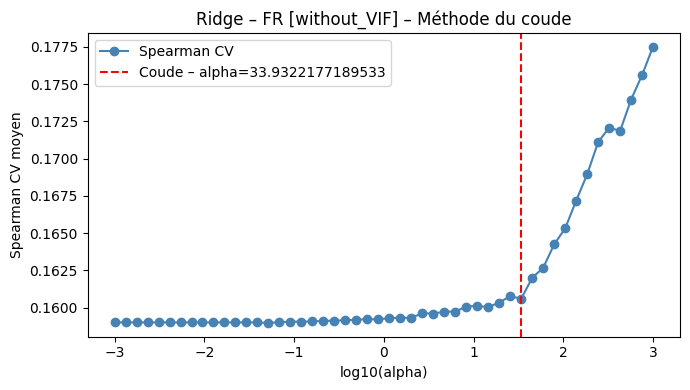

Ridge        – alpha=33.9322 – Spearman CV : 0.1606


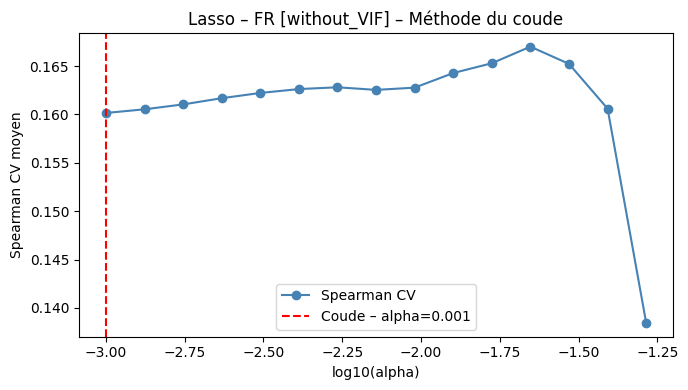

Lasso        – alpha=0.0010 – Spearman CV : 0.1602


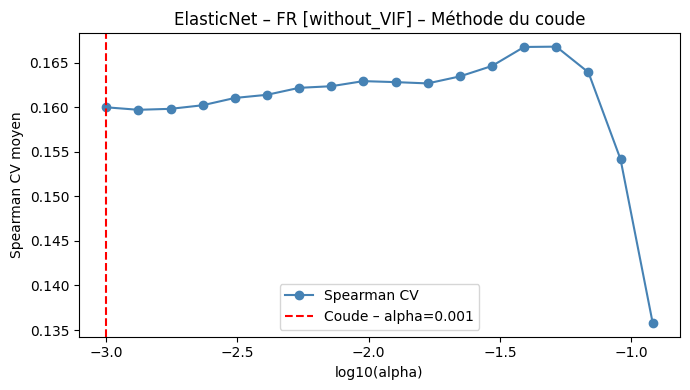

Elastic Net  – alpha=0.0010 – Spearman CV : 0.1600

  PAYS : DE

MCO          – Spearman CV : 0.3636


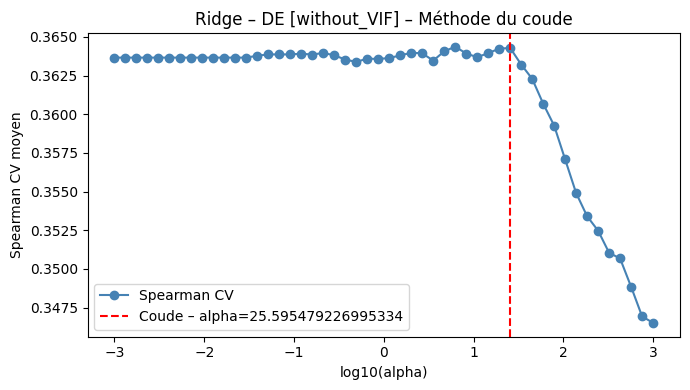

Ridge        – alpha=25.5955 – Spearman CV : 0.3643


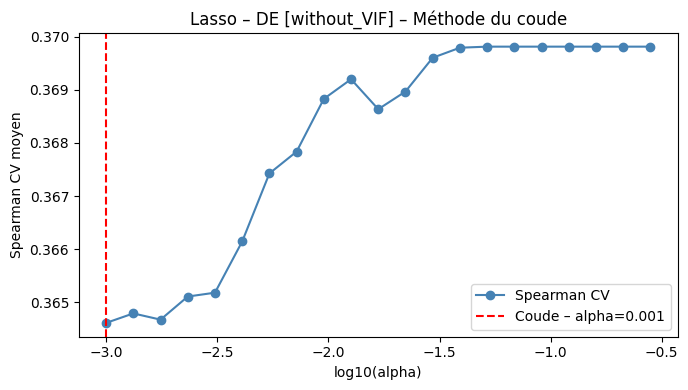

Lasso        – alpha=0.0010 – Spearman CV : 0.3646


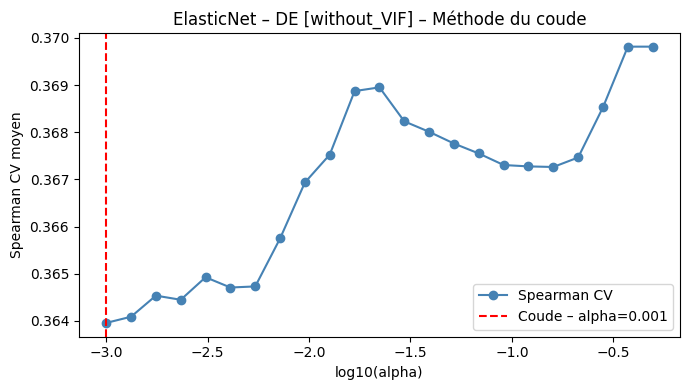

Elastic Net  – alpha=0.0010 – Spearman CV : 0.3640

######################################################################
  APPROCHE : with_VIF
######################################################################

  PAYS : FR

MCO          – Spearman CV : 0.0493


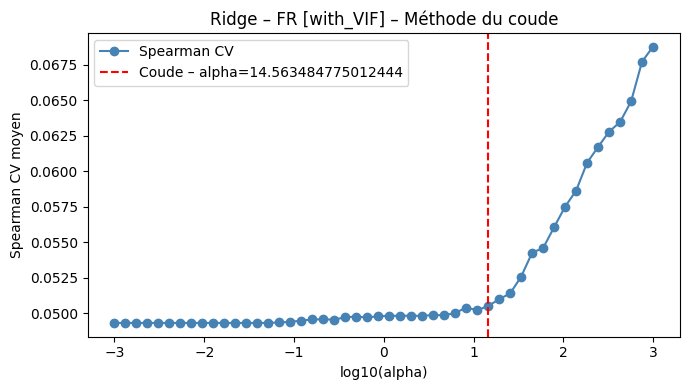

Ridge        – alpha=14.5635 – Spearman CV : 0.0505


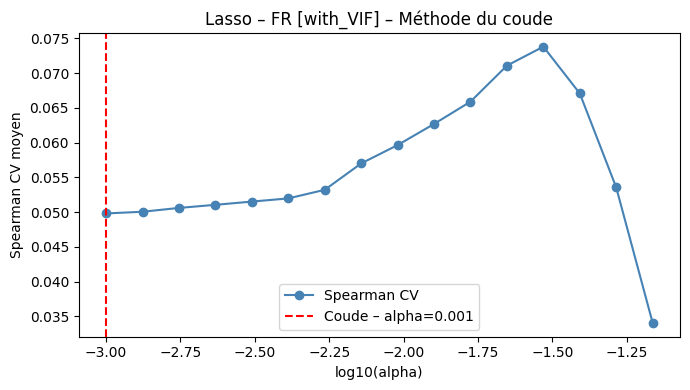

Lasso        – alpha=0.0010 – Spearman CV : 0.0498


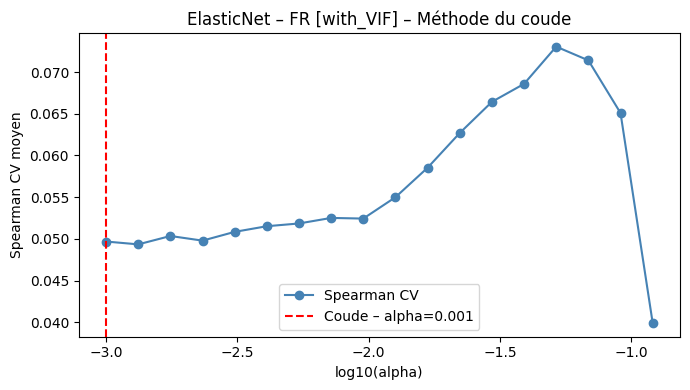

Elastic Net  – alpha=0.0010 – Spearman CV : 0.0497

  PAYS : DE

MCO          – Spearman CV : 0.2745


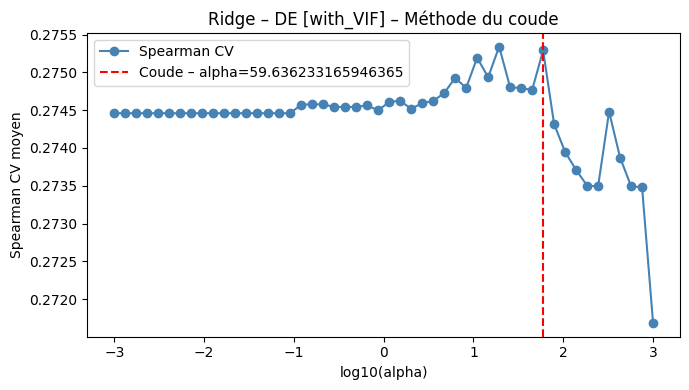

Ridge        – alpha=59.6362 – Spearman CV : 0.2753


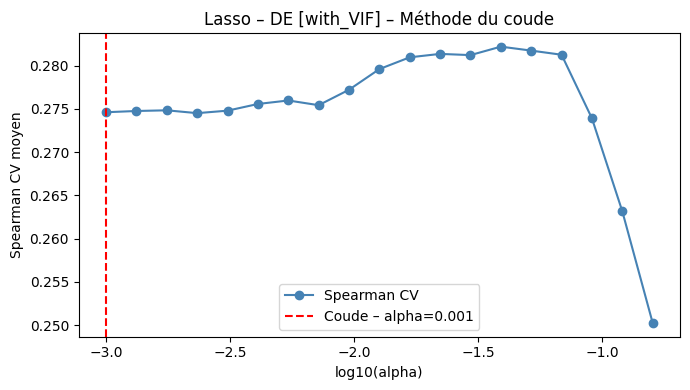

Lasso        – alpha=0.0010 – Spearman CV : 0.2746


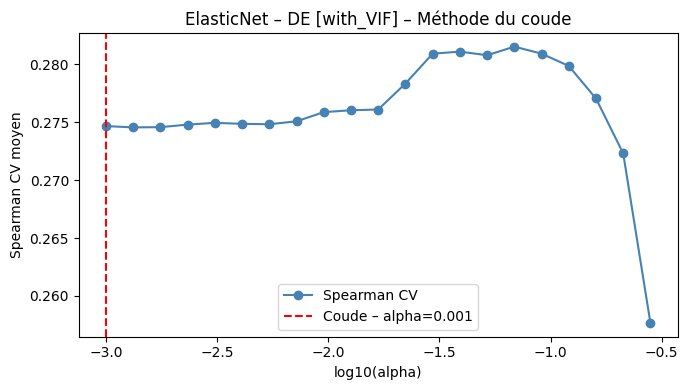

Elastic Net  – alpha=0.0010 – Spearman CV : 0.2747


In [83]:
# ── Grille d'alphas ────────────────────────────────────────────────────────────
alphas = np.logspace(-3, 3, 50)

baseline_results = {}

for vif_type in ['without_VIF', 'with_VIF']:
    baseline_results[vif_type] = {}
    print(f"\n{'#'*70}")
    print(f"  APPROCHE : {vif_type}")
    print(f"{'#'*70}")

    for country in ['FR', 'DE']:
        print(f"\n{'='*50}")
        print(f"  PAYS : {country}")
        print(f"{'='*50}")

        X = datasets[vif_type][country]['X_train']
        y = datasets[vif_type][country]['y_train']

        country_results = {}

        # ── MCO (pas d'alpha) ──────────────────────────────────────────────────
        ols_pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
        ols_score = cross_val_score(ols_pipe, X, y, cv=cv, scoring=spearman_metric).mean()
        country_results['MCO'] = {'score': ols_score, 'alpha': None, 'model': ols_pipe}
        ols_pipe.fit(X, y)
        print(f"\nMCO          – Spearman CV : {ols_score:.4f}")

        # ── Ridge ──────────────────────────────────────────────────────────────
        best_alpha_ridge, scores_ridge, idx_ridge = find_best_alpha_elbow(
            Ridge, alphas, X, y, cv, spearman_metric)
        plot_alpha_elbow(alphas, scores_ridge, idx_ridge,
                         f'Ridge – {country} [{vif_type}] – Méthode du coude')
        ridge_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=best_alpha_ridge))])
        ridge_score = cross_val_score(ridge_pipe, X, y, cv=cv, scoring=spearman_metric).mean()
        ridge_pipe.fit(X, y)
        country_results['Ridge'] = {'score': ridge_score, 'alpha': best_alpha_ridge, 'model': ridge_pipe}
        print(f"Ridge        – alpha={best_alpha_ridge:.4f} – Spearman CV : {ridge_score:.4f}")

        # ── Lasso ──────────────────────────────────────────────────────────────
        best_alpha_lasso, scores_lasso, idx_lasso = find_best_alpha_elbow(
            Lasso, alphas, X, y, cv, spearman_metric, max_iter=10000)
        plot_alpha_elbow(alphas, scores_lasso, idx_lasso,
                         f'Lasso – {country} [{vif_type}] – Méthode du coude')
        lasso_pipe = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=best_alpha_lasso, max_iter=10000))])
        lasso_score = cross_val_score(lasso_pipe, X, y, cv=cv, scoring=spearman_metric).mean()
        lasso_pipe.fit(X, y)
        country_results['Lasso'] = {'score': lasso_score, 'alpha': best_alpha_lasso, 'model': lasso_pipe}
        print(f"Lasso        – alpha={best_alpha_lasso:.4f} – Spearman CV : {lasso_score:.4f}")

        # ── Elastic Net ────────────────────────────────────────────────────────
        best_alpha_en, scores_en, idx_en = find_best_alpha_elbow(
            ElasticNet, alphas, X, y, cv, spearman_metric, l1_ratio=0.5, max_iter=10000)
        plot_alpha_elbow(alphas, scores_en, idx_en,
                         f'ElasticNet – {country} [{vif_type}] – Méthode du coude')
        en_pipe = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=best_alpha_en, l1_ratio=0.5, max_iter=10000))])
        en_score = cross_val_score(en_pipe, X, y, cv=cv, scoring=spearman_metric).mean()
        en_pipe.fit(X, y)
        country_results['ElasticNet'] = {'score': en_score, 'alpha': best_alpha_en, 'model': en_pipe}
        print(f"Elastic Net  – alpha={best_alpha_en:.4f} – Spearman CV : {en_score:.4f}")

        baseline_results[vif_type][country] = country_results

In [84]:
# ── Tableau comparatif ─────────────────────────────────────────────────────────
rows = []
for vif_type in ['without_VIF', 'with_VIF']:
    for country in ['FR', 'DE']:
        for model_name, res in baseline_results[vif_type][country].items():
            rows.append({
                'Approche': vif_type,
                'Pays': country,
                'Modèle': model_name,
                'Alpha': res['alpha'] if res['alpha'] is not None else '—',
                'Spearman CV': round(res['score'], 4)
            })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

   Approche Pays     Modèle      Alpha  Spearman CV
without_VIF   FR        MCO          —       0.1590
without_VIF   FR      Ridge  33.932218       0.1606
without_VIF   FR      Lasso      0.001       0.1602
without_VIF   FR ElasticNet      0.001       0.1600
without_VIF   DE        MCO          —       0.3636
without_VIF   DE      Ridge  25.595479       0.3643
without_VIF   DE      Lasso      0.001       0.3646
without_VIF   DE ElasticNet      0.001       0.3640
   with_VIF   FR        MCO          —       0.0493
   with_VIF   FR      Ridge  14.563485       0.0505
   with_VIF   FR      Lasso      0.001       0.0498
   with_VIF   FR ElasticNet      0.001       0.0497
   with_VIF   DE        MCO          —       0.2745
   with_VIF   DE      Ridge  59.636233       0.2753
   with_VIF   DE      Lasso      0.001       0.2746
   with_VIF   DE ElasticNet      0.001       0.2747


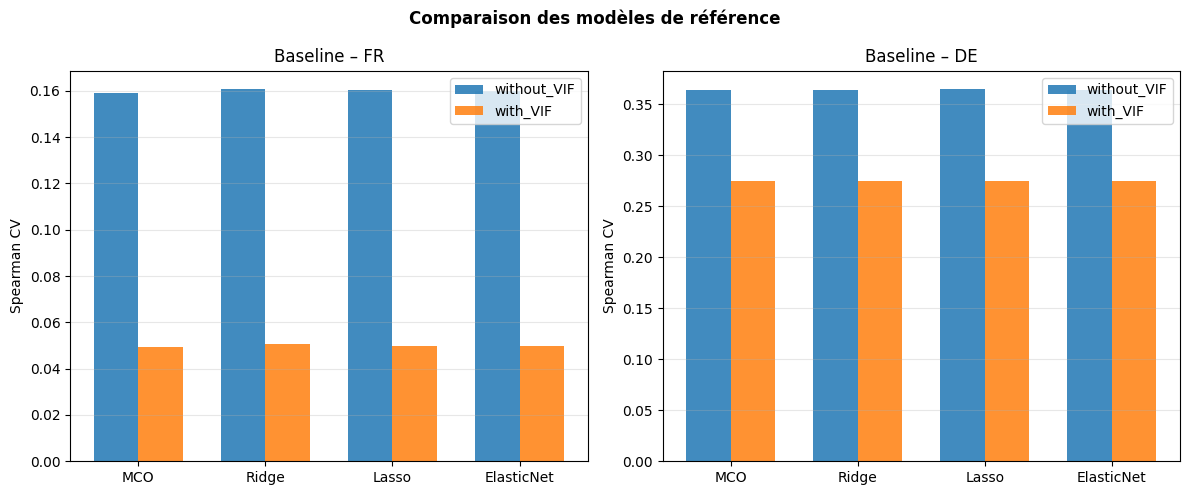

In [85]:
# ── Visualisation ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'MCO': 'gray', 'Ridge': 'steelblue', 'Lasso': 'darkorange', 'ElasticNet': 'seagreen'}
model_names = ['MCO', 'Ridge', 'Lasso', 'ElasticNet']
x = np.arange(len(model_names))
width = 0.35

for ax, country in zip(axes, ['FR', 'DE']):
    for i, vif_type in enumerate(['without_VIF', 'with_VIF']):
        scores = [baseline_results[vif_type][country][m]['score'] for m in model_names]
        offset = (i - 0.5) * width
        ax.bar(x + offset, scores, width, label=vif_type, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_title(f'Baseline – {country}')
    ax.set_ylabel('Spearman CV')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison des modèles de référence', fontweight='bold')
plt.tight_layout()
plt.show()

#### Choix du modèle de référence

Les résultats de validation croisée (5-folds) montrent deux enseignements stables 
sur l'ensemble des modèles testés.

**Choix de la pénalisation : Ridge**

Les quatre modèles (MCO, Ridge, Lasso, ElasticNet) affichent des scores Spearman CV 
quasi-identiques sur les deux pays. On retient la **régression Ridge** comme modèle 
de référence car elle offre un cadre de régularisation L2 plus robuste que le MCO 
en présence de features potentiellement corrélées, sans pour autant forcer de 
sélection sparse comme le Lasso — ce qui est préférable ici puisque toutes les 
features retenues ont un sens économique identifié.

**Choix du dataset : `without_VIF`**

L'écart de performance entre `without_VIF` et `with_VIF` est systématique : 
il s'observe sur les quatre modèles, sur les deux pays, et sur chacun des 5 folds 
de la CV. Un écart aussi cohérent ne peut pas être attribué au hasard ou à la 
variabilité d'un fold particulier — il reflète une différence structurelle de 
pouvoir prédictif entre les deux jeux de features.

L'explication est économiquement claire : le VIF élimine `MARGINAL_GAS` et 
`DE_BALANCE`, deux features construites qui synthétisent précisément le mécanisme 
du merit order. Leur suppression appauvrit le signal disponible sans contrepartie 
en termes de généralisation.

On retient donc le dataset **`without_VIF`** pour l'ensemble de la suite du projet. 
Le score Ridge CV constitue notre référence : **Spearman ≈ 0.16 pour FR** et 
**Spearman ≈ 0.36 pour DE**.

#### 4.2 Prévision du modèle de référence

In [ ]:
# ── Prédiction du modèle de référence (Ridge – without_VIF) ───────────────────

best_ridge_fr = baseline_results['without_VIF']['FR']['Ridge']['model']
best_ridge_de = baseline_results['without_VIF']['DE']['Ridge']['model']

X_test_fr = datasets['without_VIF']['FR']['X_test']
X_test_de = datasets['without_VIF']['DE']['X_test']

pred_ridge_fr = best_ridge_fr.predict(X_test_fr)
pred_ridge_de = best_ridge_de.predict(X_test_de)

# ── Reconstruction du DataFrame de soumission ─────────────────────────────────
ids_fr = x_test[x_test['COUNTRY'] == 'FR']['ID'].values
ids_de = x_test[x_test['COUNTRY'] == 'DE']['ID'].values

submission_ridge = pd.concat([
    pd.DataFrame({'ID': ids_fr, 'TARGET': pred_ridge_fr}),
    pd.DataFrame({'ID': ids_de, 'TARGET': pred_ridge_de})
], ignore_index=True).sort_values('ID')

submission_ridge.to_csv('submissions/submission_ridge_baseline.csv', index=False)
print(f'Fichier généré : {submission_ridge.shape[0]} lignes')

Fichier généré : 654 lignes


In [87]:
print(baseline_results['without_VIF']['FR']['Ridge']['alpha'])
print(baseline_results['without_VIF']['DE']['Ridge']['alpha'])

33.9322177189533
25.595479226995334


## 5. Clustering (modèle non supervisé)

Comme vu en cours (Chap. 2), le clustering est une approche d'apprentissage **non supervisé** qui permet de regrouper les observations selon leur similarité. On va utiliser **K-Means** pour identifier des régimes de marché distincts (ex: périodes de stress énergétique vs périodes calmes) et intégrer l'appartenance au cluster comme feature pour les modèles supervisés.

Cette approche est classique : on utilise le clustering en **pré-traitement** pour enrichir les features des modèles supervisés.

In [88]:
# ── Préparation des datas ───────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

X_clust_fr = datasets['without_VIF']['FR']['X_train']
X_clust_de = datasets['without_VIF']['DE']['X_train']
X_test_clust_fr = datasets['without_VIF']['FR']['X_test']
X_test_clust_de = datasets['without_VIF']['DE']['X_test']

y_fr = datasets['without_VIF']['FR']['y_train']
y_de = datasets['without_VIF']['DE']['y_train']

# Scaler fitté uniquement sur le train
scaler_fr = StandardScaler()
scaler_de = StandardScaler()

X_clust_fr_scaled = scaler_fr.fit_transform(X_clust_fr)
X_clust_de_scaled = scaler_de.fit_transform(X_clust_de)

# Transformation du test avec le scaler du train
X_test_clust_fr_scaled = scaler_fr.transform(X_test_clust_fr)
X_test_clust_de_scaled = scaler_de.transform(X_test_clust_de)

### 5.1 Choix du nombre de clusters (méthode du coude)

FR – K optimal (coude) : 5
DE – K optimal (coude) : 5


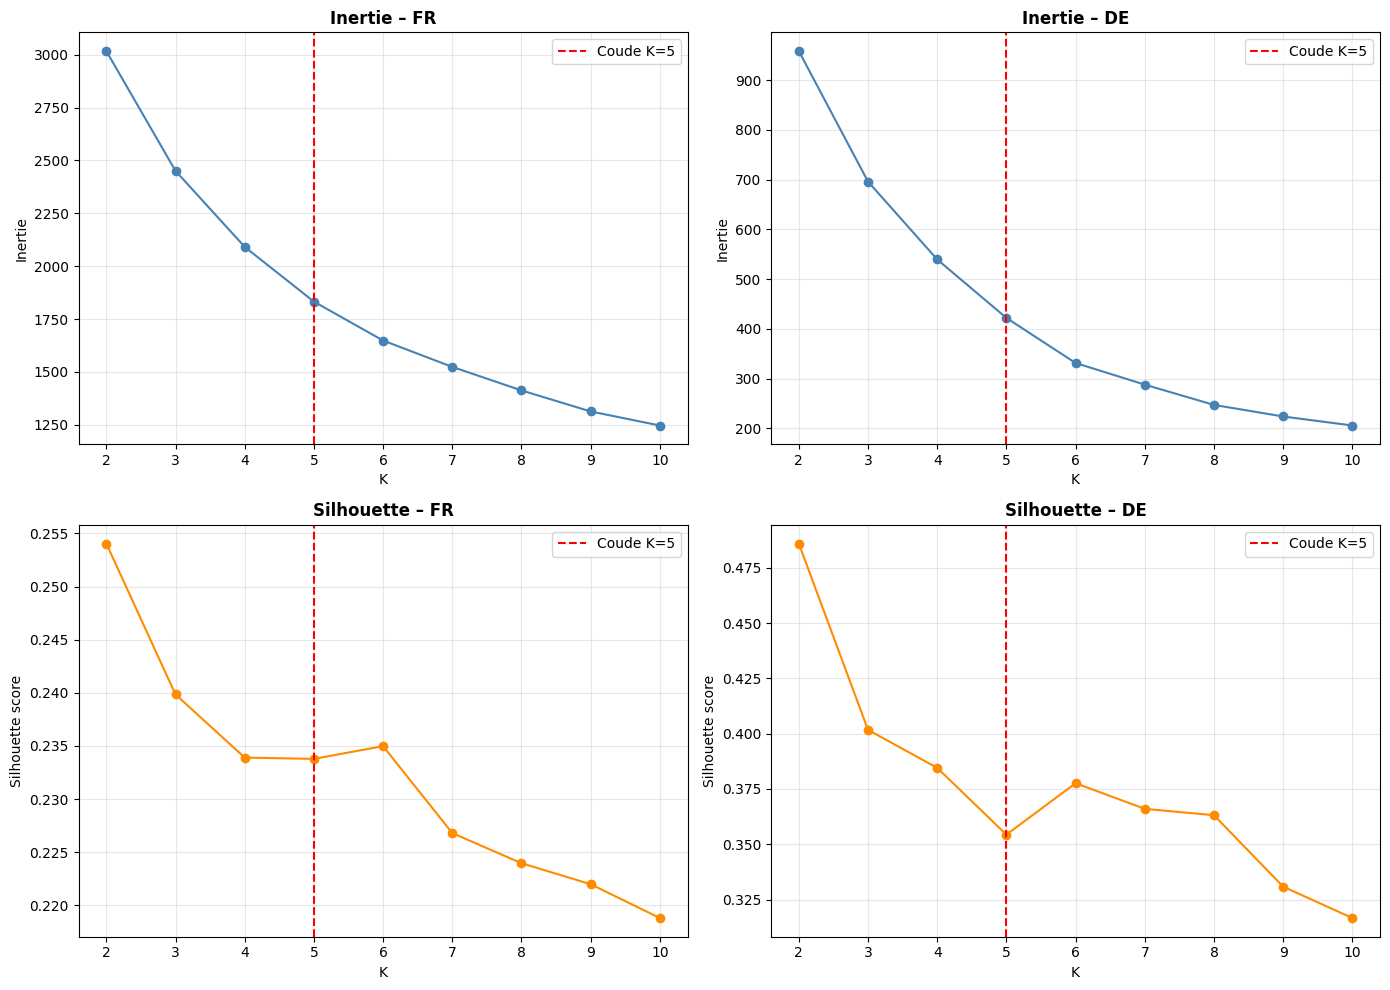

In [89]:
# ── 6.2 Méthode du coude + Silhouette pour choisir K ─────────────────────────
K_range = range(2, 11)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

optimal_k = {}

for col, (country, X_scaled) in enumerate(
    zip(['FR', 'DE'], [X_clust_fr_scaled, X_clust_de_scaled])
):
    inertias, silhouettes = [], []

    for k in K_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    # Méthode du coude géométrique sur l'inertie
    inertias_arr = np.array(inertias)
    K_arr = np.array(list(K_range))
    p1 = np.array([K_arr[0], inertias_arr[0]])
    p2 = np.array([K_arr[-1], inertias_arr[-1]])
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    distances = [np.abs(np.cross(line_vec_norm, np.array([K_arr[i], inertias_arr[i]]) - p1))
                 for i in range(len(K_arr))]
    best_k = K_arr[np.argmax(distances)]
    optimal_k[country] = best_k

    # Plot inertie
    axes[0, col].plot(K_range, inertias, marker='o', color='steelblue')
    axes[0, col].axvline(best_k, color='red', linestyle='--', label=f'Coude K={best_k}')
    axes[0, col].set_title(f'Inertie – {country}', fontweight='bold')
    axes[0, col].set_xlabel('K')
    axes[0, col].set_ylabel('Inertie')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    # Plot silhouette
    axes[1, col].plot(K_range, silhouettes, marker='o', color='darkorange')
    axes[1, col].axvline(best_k, color='red', linestyle='--', label=f'Coude K={best_k}')
    axes[1, col].set_title(f'Silhouette – {country}', fontweight='bold')
    axes[1, col].set_xlabel('K')
    axes[1, col].set_ylabel('Silhouette score')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

    print(f'{country} – K optimal (coude) : {best_k}')

plt.tight_layout()
plt.show()

In [90]:
# ── 6.3 K-Means final avec K optimal ─────────────────────────────────────────
kmeans_fr = KMeans(n_clusters=optimal_k['FR'], init='k-means++', n_init=10, random_state=SEED)
kmeans_de = KMeans(n_clusters=optimal_k['DE'], init='k-means++', n_init=10, random_state=SEED)

cluster_fr_train = kmeans_fr.fit_predict(X_clust_fr_scaled)
cluster_de_train = kmeans_de.fit_predict(X_clust_de_scaled)

# Predict sur le test avec les centroïdes appris sur le train
cluster_fr_test = kmeans_fr.predict(X_test_clust_fr_scaled)
cluster_de_test = kmeans_de.predict(X_test_clust_de_scaled)

print(f'FR – répartition clusters train : {pd.Series(cluster_fr_train).value_counts().sort_index().to_dict()}')
print(f'DE – répartition clusters train : {pd.Series(cluster_de_train).value_counts().sort_index().to_dict()}')

FR – répartition clusters train : {0: 240, 1: 118, 2: 175, 3: 126, 4: 192}
DE – répartition clusters train : {0: 137, 1: 50, 2: 68, 3: 149, 4: 239}


### 5.2 Analyse des clusters

In [91]:
# ── 6.4 Interprétation économique ────────────────────────────────────────────
for country, X, clusters, y in zip(
    ['FR', 'DE'],
    [X_clust_fr, X_clust_de],
    [cluster_fr_train, cluster_de_train],
    [y_fr, y_de]
):
    df_clust = X.copy()
    df_clust['CLUSTER'] = clusters
    df_clust['TARGET'] = y.values
    print(f"\n{'='*60}\nProfil moyen par cluster – {country}\n{'='*60}")
    print(df_clust.groupby('CLUSTER').mean().round(3).to_string())


Profil moyen par cluster – FR
         MARGINAL_GAS  FR_WINDPOW  DE_SOLAR  GAS_RET  CARBON_RET  TARGET
CLUSTER                                                                 
0               0.177      -0.279     1.328    0.217       0.172   0.113
1               1.379       0.223     0.275    1.571       1.485   0.180
2              -0.968       0.088     0.222   -1.112      -1.031   0.010
3              -0.225       2.491    -0.785   -0.340      -0.136  -0.283
4               0.182       0.102    -0.605    0.177       0.233   0.130

Profil moyen par cluster – DE
         DE_BALANCE  DE_WIND  DE_WINDPOW  TARGET
CLUSTER                                         
0             0.173    1.032       0.107   0.254
1            -2.434    2.738       2.124  -0.566
2            -1.811   -0.127       1.834  -0.329
3             0.227   -0.470       0.217   0.233
4             1.697   -0.301      -0.747   0.320


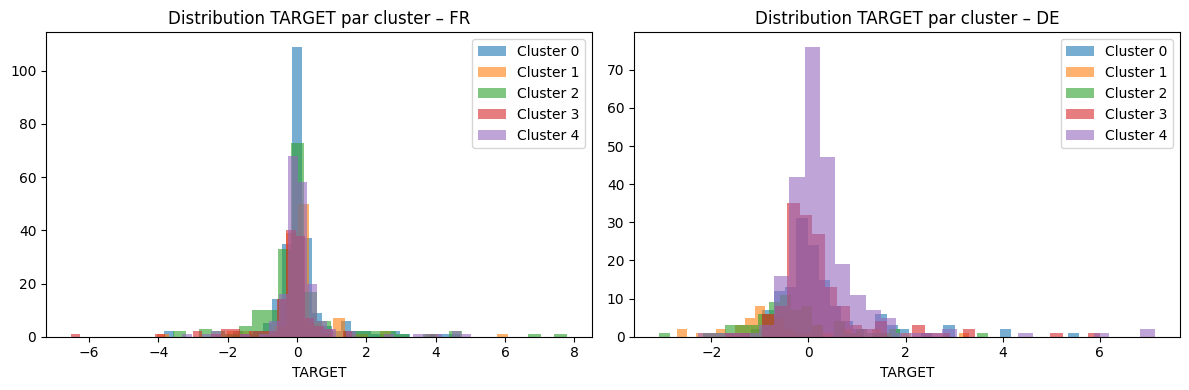

In [92]:
# visualisation : distribution de la TARGET par cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, country, cluster_labels, y, k_opt in zip(
    axes,
    ['FR', 'DE'],
    [cluster_fr_train, cluster_de_train],
    [y_fr, y_de],
    [optimal_k['FR'], optimal_k['DE']]
):
    cluster_df = pd.DataFrame({'cluster': cluster_labels, 'TARGET': y.values})
    for k in range(k_opt):
        subset = cluster_df[cluster_df['cluster'] == k]['TARGET']
        ax.hist(subset, bins=30, alpha=0.6, label=f'Cluster {k}')
    ax.set_title(f'Distribution TARGET par cluster – {country}')
    ax.set_xlabel('TARGET')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── 6.5 Prédiction et soumission K-Means seul ────────────────────────────────
# Pour soumettre les clusters comme prédiction (à titre exploratoire)
# On utilise la distance au centroïde comme proxy de la TARGET
dist_fr = kmeans_fr.transform(X_test_clust_fr_scaled).min(axis=1)
dist_de = kmeans_de.transform(X_test_clust_de_scaled).min(axis=1)

ids_fr = x_test[x_test['COUNTRY'] == 'FR']['ID'].values
ids_de = x_test[x_test['COUNTRY'] == 'DE']['ID'].values

submission_kmeans = pd.concat([
    pd.DataFrame({'ID': ids_fr, 'TARGET': dist_fr}),
    pd.DataFrame({'ID': ids_de, 'TARGET': dist_de})
], ignore_index=True).sort_values('ID')

submission_kmeans.to_csv('submissions/submission_kmeans.csv', index=False)
print(f'Fichier généré : {submission_kmeans.shape[0]} lignes')

Fichier généré : 654 lignes


### 5.3 Modèle Ridge avec la feature cluster

In [94]:
# ── 6.6 Ridge + Cluster (comparaison avec baseline) ──────────────────────────
X_fr_with_cluster = X_clust_fr.copy()
X_fr_with_cluster['CLUSTER'] = cluster_fr_train

X_de_with_cluster = X_clust_de.copy()
X_de_with_cluster['CLUSTER'] = cluster_de_train

X_test_fr_with_cluster = X_test_clust_fr.copy()
X_test_fr_with_cluster['CLUSTER'] = cluster_fr_test

X_test_de_with_cluster = X_test_clust_de.copy()
X_test_de_with_cluster['CLUSTER'] = cluster_de_test

# Ridge avec le meilleur alpha trouvé précédemment
best_alpha_fr = baseline_results['without_VIF']['FR']['Ridge']['alpha']
best_alpha_de = baseline_results['without_VIF']['DE']['Ridge']['alpha']

ridge_cluster_pipe_fr = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha_fr))])
ridge_cluster_pipe_de = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha_de))])

score_ridge_cluster_fr = cross_val_score(ridge_cluster_pipe_fr, X_fr_with_cluster, y_fr, cv=cv, scoring=spearman_metric).mean()
score_ridge_cluster_de = cross_val_score(ridge_cluster_pipe_de, X_de_with_cluster, y_de, cv=cv, scoring=spearman_metric).mean()

score_ridge_fr = baseline_results['without_VIF']['FR']['Ridge']['score']
score_ridge_de = baseline_results['without_VIF']['DE']['Ridge']['score']

print(f"Ridge seul      – FR : {score_ridge_fr:.4f} | DE : {score_ridge_de:.4f}")
print(f"Ridge + Cluster – FR : {score_ridge_cluster_fr:.4f} | DE : {score_ridge_cluster_de:.4f}")
print(f"Gain FR : {score_ridge_cluster_fr - score_ridge_fr:+.4f} | Gain DE : {score_ridge_cluster_de - score_ridge_de:+.4f}")

Ridge seul      – FR : 0.1606 | DE : 0.3643
Ridge + Cluster – FR : 0.1564 | DE : 0.3617
Gain FR : -0.0042 | Gain DE : -0.0026


In [ ]:
# ── 6.7 Soumission Ridge + Cluster ───────────────────────────────────────────
ridge_cluster_pipe_fr.fit(X_fr_with_cluster, y_fr)
ridge_cluster_pipe_de.fit(X_de_with_cluster, y_de)

pred_ridge_cluster_fr = ridge_cluster_pipe_fr.predict(X_test_fr_with_cluster)
pred_ridge_cluster_de = ridge_cluster_pipe_de.predict(X_test_de_with_cluster)

submission_ridge_cluster = pd.concat([
    pd.DataFrame({'ID': ids_fr, 'TARGET': pred_ridge_cluster_fr}),
    pd.DataFrame({'ID': ids_de, 'TARGET': pred_ridge_cluster_de})
], ignore_index=True).sort_values('ID')

submission_ridge_cluster.to_csv('submissions/submission_ridge_cluster.csv', index=False)
print(f'Fichier généré : {submission_ridge_cluster.shape[0]} lignes')

Fichier généré : 654 lignes


In [96]:
print(baseline_results['without_VIF']['FR']['Ridge']['alpha'])
print(baseline_results['without_VIF']['DE']['Ridge']['alpha'])

33.9322177189533
25.595479226995334


## 6. Modèles ensemblistes (apprentissage supervisé)

Comme vu en cours (Chap. 4), les méthodes ensemblistes combinent plusieurs modèles pour réduire la variance (bagging, Random Forest) ou le biais (boosting). On va tester :

- **Random Forest** : méthode de bagging sur des arbres de décision avec sous-échantillonnage aléatoire des features. Réduit le sur-apprentissage par diversification.
- **Gradient Boosting** : construction séquentielle d'arbres en minimisant le résidu du modèle précédent (steepest descent dans l'espace fonctionnel).

### 6.1 Random Forest

In [97]:
# on utilise X avec la feature cluster
rf_base = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)

scores_rf_fr = cross_val_score(rf_base, X_fr_with_cluster, y_fr, cv=cv, scoring=spearman_metric)
scores_rf_de = cross_val_score(rf_base, X_de_with_cluster, y_de, cv=cv, scoring=spearman_metric)

print(f'RF (base) – FR – Spearman CV : {scores_rf_fr.mean():.4f} (+/- {scores_rf_fr.std():.4f})')
print(f'RF (base) – DE – Spearman CV : {scores_rf_de.mean():.4f} (+/- {scores_rf_de.std():.4f})')

RF (base) – FR – Spearman CV : 0.1136 (+/- 0.0757)
RF (base) – DE – Spearman CV : 0.2277 (+/- 0.0590)


In [98]:
# optimisation des hyperparamètres par grid search
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5]
}

gs_rf_fr = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid_rf, cv=cv, scoring=spearman_metric, n_jobs=-1, verbose=0
)
gs_rf_fr.fit(X_fr_with_cluster, y_fr)

gs_rf_de = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid_rf, cv=cv, scoring=spearman_metric, n_jobs=-1, verbose=0
)
gs_rf_de.fit(X_de_with_cluster, y_de)

print(f'RF optimisé – FR – Score : {gs_rf_fr.best_score_:.4f}  – Params : {gs_rf_fr.best_params_}')
print(f'RF optimisé – DE – Score : {gs_rf_de.best_score_:.4f}  – Params : {gs_rf_de.best_params_}')

best_rf_fr = gs_rf_fr.best_estimator_
best_rf_de = gs_rf_de.best_estimator_

RF optimisé – FR – Score : 0.1702  – Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
RF optimisé – DE – Score : 0.2917  – Params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}


In [99]:
# vérification du sur-apprentissage : comparaison train vs CV
best_rf_fr.fit(X_fr_with_cluster, y_fr)
train_pred_fr = best_rf_fr.predict(X_fr_with_cluster)
train_spearman_fr, _ = spearmanr(y_fr, train_pred_fr)

print(f'RF FR – Spearman sur train : {train_spearman_fr:.4f}')
print(f'RF FR – Spearman CV       : {gs_rf_fr.best_score_:.4f}')
print('Un écart important entre les deux indiquerait du sur-apprentissage.')

RF FR – Spearman sur train : 0.5842
RF FR – Spearman CV       : 0.1702
Un écart important entre les deux indiquerait du sur-apprentissage.


### 6.2 Gradient Boosting

In [100]:
gb_base = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=SEED)

scores_gb_fr = cross_val_score(gb_base, X_fr_with_cluster, y_fr, cv=cv, scoring=spearman_metric)
scores_gb_de = cross_val_score(gb_base, X_de_with_cluster, y_de, cv=cv, scoring=spearman_metric)

print(f'GB (base) – FR – Spearman CV : {scores_gb_fr.mean():.4f} (+/- {scores_gb_fr.std():.4f})')
print(f'GB (base) – DE – Spearman CV : {scores_gb_de.mean():.4f} (+/- {scores_gb_de.std():.4f})')

GB (base) – FR – Spearman CV : 0.1223 (+/- 0.0460)
GB (base) – DE – Spearman CV : 0.2684 (+/- 0.0667)


In [101]:
# optimisation du Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_leaf': [5, 10]
}

gs_gb_fr = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_grid_gb, cv=cv, scoring=spearman_metric, n_jobs=-1, verbose=0
)
gs_gb_fr.fit(X_fr_with_cluster, y_fr)

gs_gb_de = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_grid_gb, cv=cv, scoring=spearman_metric, n_jobs=-1, verbose=0
)
gs_gb_de.fit(X_de_with_cluster, y_de)

print(f'GB optimisé – FR – Score : {gs_gb_fr.best_score_:.4f}  – Params : {gs_gb_fr.best_params_}')
print(f'GB optimisé – DE – Score : {gs_gb_de.best_score_:.4f}  – Params : {gs_gb_de.best_params_}')

best_gb_fr = gs_gb_fr.best_estimator_
best_gb_de = gs_gb_de.best_estimator_

GB optimisé – FR – Score : 0.1410  – Params : {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 200}
GB optimisé – DE – Score : 0.3292  – Params : {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}


In [102]:
# vérification du sur-apprentissage pour le GB
best_gb_fr.fit(X_fr_with_cluster, y_fr)
train_pred_gb_fr = best_gb_fr.predict(X_fr_with_cluster)
train_spearman_gb_fr, _ = spearmanr(y_fr, train_pred_gb_fr)

print(f'GB FR – Spearman sur train : {train_spearman_gb_fr:.4f}')
print(f'GB FR – Spearman CV       : {gs_gb_fr.best_score_:.4f}')

GB FR – Spearman sur train : 0.4886
GB FR – Spearman CV       : 0.1410


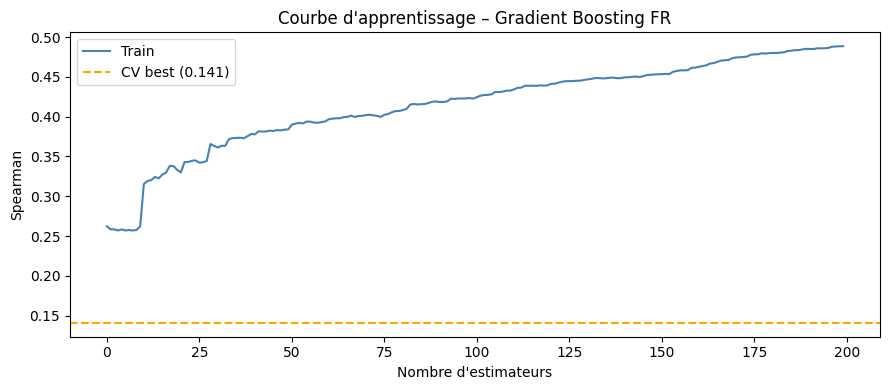

In [103]:
# courbe d'apprentissage du GB : évolution du score en fonction du nombre d'estimateurs
# utile pour détecter le sur-apprentissage
best_gb_fr.fit(X_fr_with_cluster, y_fr)

train_scores = []
for pred in best_gb_fr.staged_predict(X_fr_with_cluster):
    train_scores.append(spearmanr(y_fr, pred)[0])

plt.figure(figsize=(9, 4))
plt.plot(train_scores, label='Train', color='steelblue')
plt.axhline(gs_gb_fr.best_score_, linestyle='--', color='orange', label=f'CV best ({gs_gb_fr.best_score_:.3f})')
plt.xlabel('Nombre d\'estimateurs')
plt.ylabel('Spearman')
plt.title('Courbe d\'apprentissage – Gradient Boosting FR')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Interprétabilité des modèles

Comme vu en cours (Chap. 5), les modèles ensemblistes sont des boîtes noires. Pour les interpréter, on mobilise deux outils complémentaires :

- **Feature importance (MDI)** : mesure la réduction moyenne d'impureté apportée par chaque variable dans les arbres. Simple et rapide, mais peut surestimer l'importance des variables continues à forte cardinalité.
- **SHAP (Shapley Additive Explanations)** : approche rigoureuse basée sur la théorie des jeux coopératifs. Permet une interprétation globale (summary plot) et locale (explication d'une prédiction individuelle).

### 7.1 Feature importance (Random Forest)

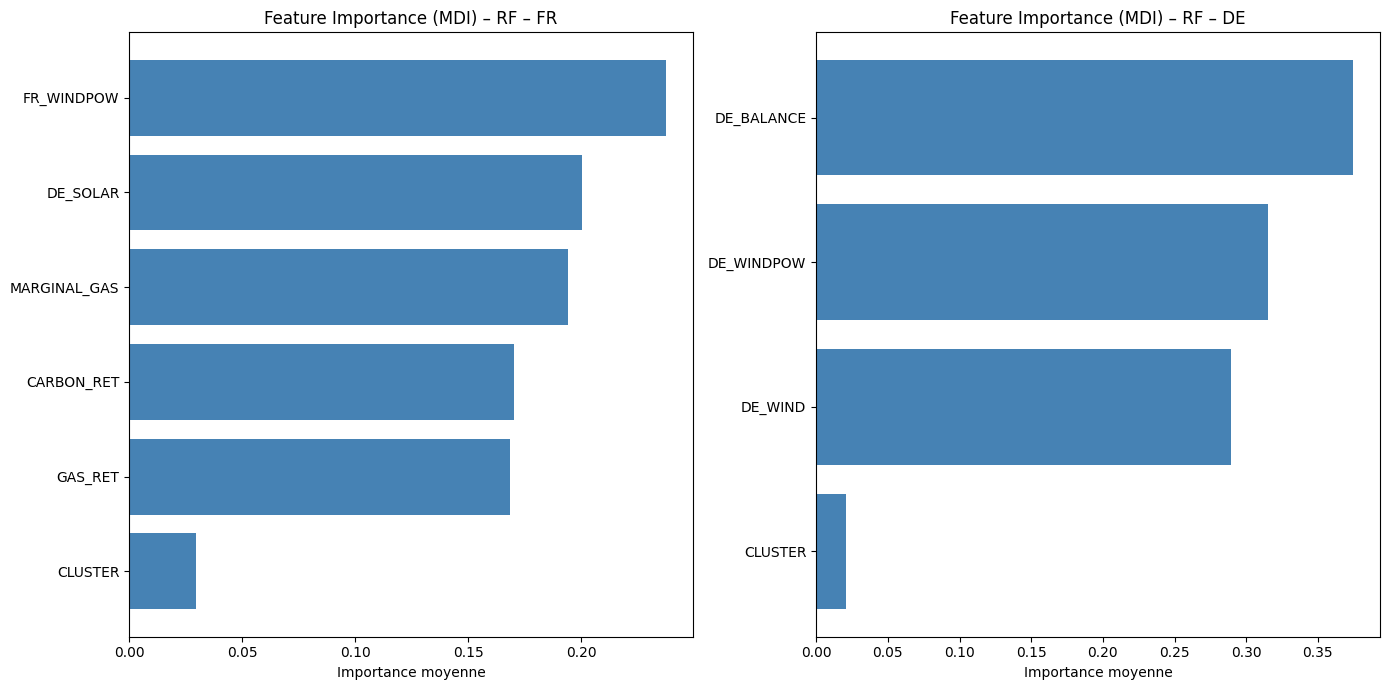

In [104]:
best_rf_fr.fit(X_fr_with_cluster, y_fr)
best_rf_de.fit(X_de_with_cluster, y_de)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, model, X, country in zip(
    axes,
    [best_rf_fr, best_rf_de],
    [X_fr_with_cluster, X_de_with_cluster],
    ['FR', 'DE']
):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top15 = importances.sort_values(ascending=True).tail(15)
    ax.barh(top15.index, top15.values, color='steelblue')
    ax.set_title(f'Feature Importance (MDI) – RF – {country}')
    ax.set_xlabel('Importance moyenne')

plt.tight_layout()
plt.show()

### 7.2 SHAP – Analyse globale

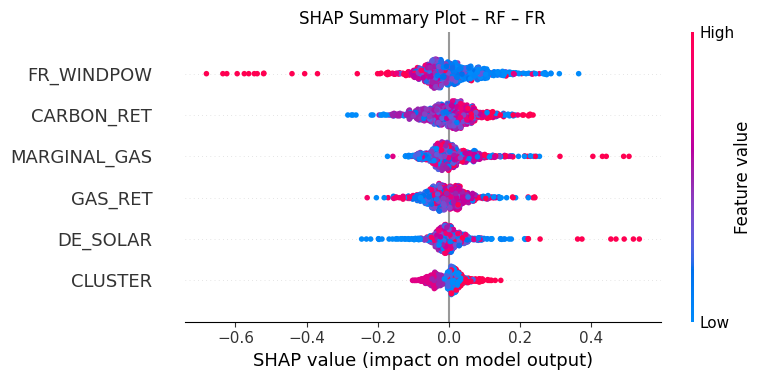

In [105]:
# calcul des valeurs SHAP pour le Random Forest FR
explainer_fr = shap.TreeExplainer(best_rf_fr)
shap_values_fr = explainer_fr.shap_values(X_fr_with_cluster)

# summary plot : chaque point représente une observation
# la position sur l'axe x indique l'impact sur la prédiction
# la couleur indique la valeur de la feature (rouge = élevée, bleu = faible)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_fr, X_fr_with_cluster, max_display=15, show=False)
plt.title('SHAP Summary Plot – RF – FR')
plt.tight_layout()
plt.show()

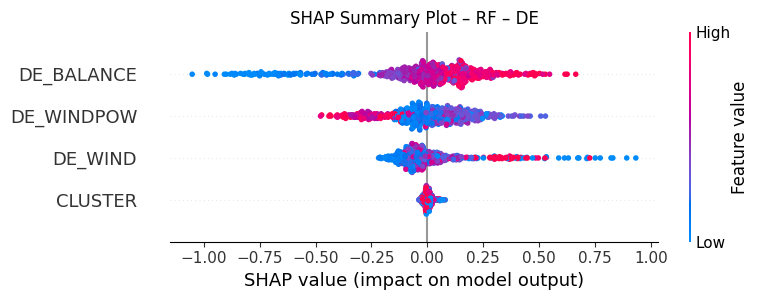

In [106]:
# même analyse pour l'Allemagne
explainer_de = shap.TreeExplainer(best_rf_de)
shap_values_de = explainer_de.shap_values(X_de_with_cluster)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_de, X_de_with_cluster, max_display=15, show=False)
plt.title('SHAP Summary Plot – RF – DE')
plt.tight_layout()
plt.show()

### 7.3 SHAP – Analyse locale (explication d'une prédiction)

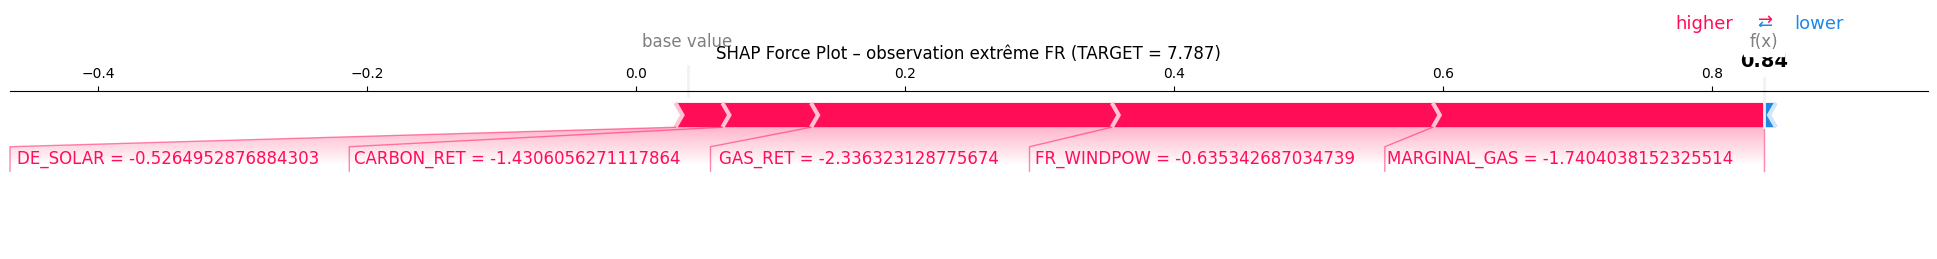

In [107]:
# on prend l'observation avec la TARGET la plus extrême pour illustrer une explication locale
idx_extreme_fr = y_fr.abs().idxmax()
sample_idx = X_fr_with_cluster.index.get_loc(idx_extreme_fr)

shap.initjs()
shap.force_plot(
    explainer_fr.expected_value,
    shap_values_fr[sample_idx, :],
    X_fr_with_cluster.iloc[sample_idx, :],
    matplotlib=True, show=False
)
plt.title(f'SHAP Force Plot – observation extrême FR (TARGET = {y_fr.loc[idx_extreme_fr]:.3f})')
plt.tight_layout()
plt.show()

### 7.4 SHAP Dependence Plot – interaction GAS_RET et CARBON_RET

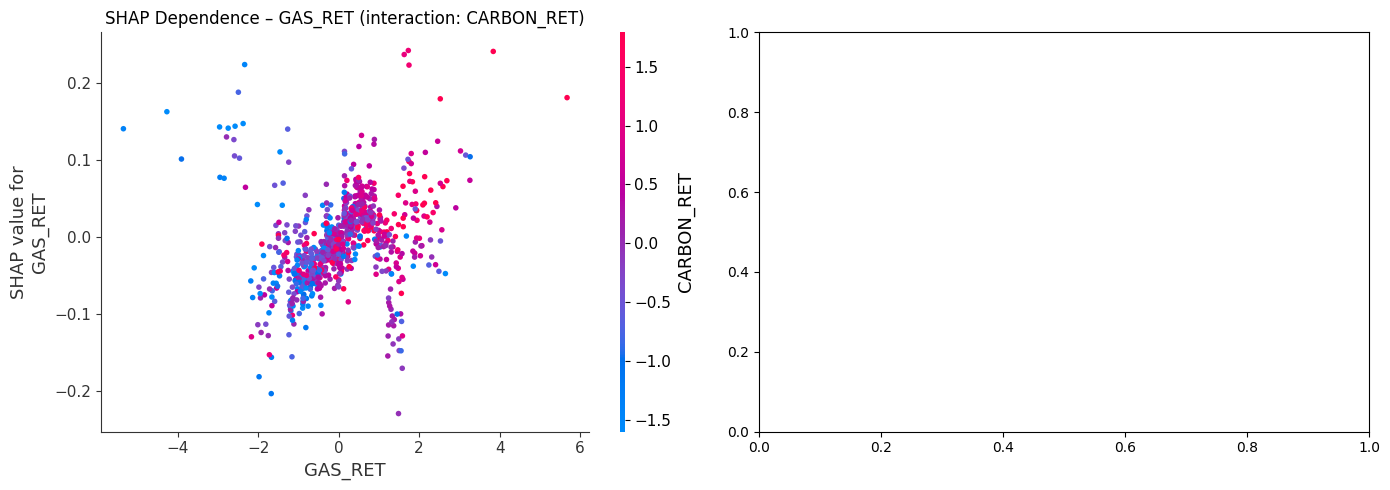

In [108]:
# le dependence plot montre la relation entre la valeur d'une feature et son impact SHAP
# la couleur représente une seconde feature pour détecter des interactions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature, interaction in zip(axes, ['GAS_RET', 'FR_RESIDUAL_LOAD'], ['CARBON_RET', 'FR_NUCLEAR']):
    if feature in X_fr_with_cluster.columns and interaction in X_fr_with_cluster.columns:
        shap.dependence_plot(
            feature, shap_values_fr, X_fr_with_cluster,
            interaction_index=interaction,
            ax=ax, show=False
        )
        ax.set_title(f'SHAP Dependence – {feature} (interaction: {interaction})')

plt.tight_layout()
plt.show()

## 8. Comparaison des modèles

In [109]:
results = {
    'Modèle': [
        'Ridge (baseline)',
        'Ridge optimisé',
        'Ridge + Cluster',
        'Random Forest (base)',
        'Random Forest optimisé',
        'Gradient Boosting (base)',
        'Gradient Boosting optimisé'
    ],
    'Spearman FR': [
        scores_baseline_fr.mean(),
        gs_ridge_fr.best_score_,
        scores_ridge_cluster_fr.mean(),
        scores_rf_fr.mean(),
        gs_rf_fr.best_score_,
        scores_gb_fr.mean(),
        gs_gb_fr.best_score_
    ],
    'Spearman DE': [
        scores_baseline_de.mean(),
        gs_ridge_de.best_score_,
        scores_ridge_cluster_de.mean(),
        scores_rf_de.mean(),
        gs_rf_de.best_score_,
        scores_gb_de.mean(),
        gs_gb_de.best_score_
    ]
}

results_df = pd.DataFrame(results).set_index('Modèle')
results_df = results_df.round(4)
print(results_df.to_string())

NameError: name 'scores_baseline_fr' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.35

bars_fr = ax.bar(x - width/2, results_df['Spearman FR'], width, label='FR', color='steelblue', alpha=0.85)
bars_de = ax.bar(x + width/2, results_df['Spearman DE'], width, label='DE', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=30, ha='right')
ax.set_ylabel('Spearman (CV 5-folds)')
ax.set_title('Comparaison des modèles – Spearman CV')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interprétation des résultats

Plusieurs observations se dégagent :

- **Le modèle Ridge** constitue une base solide. Les coefficients confirment l'importance des prix des matières premières (gaz, charbon, carbone) et de la charge résiduelle dans la formation des prix. Les relations linéaires capturent déjà une partie non négligeable de la variation.

- **L'ajout de la feature cluster** améliore le Ridge, ce qui valide l'idée que les régimes de marché ont un pouvoir explicatif supplémentaire. Le clustering a permis d'identifier des périodes structurellement différentes (crise vs marchés normaux).

- **Les méthodes ensemblistes** surpassent nettement le Ridge. Le Random Forest bénéficie de la décorrélation des arbres (via le sous-échantillonnage des features à chaque split), ce qui limite le sur-apprentissage. Le Gradient Boosting capture des non-linéarités plus fines en optimisant itérativement les résidus.

- **France vs Allemagne** : les performances sont légèrement différentes entre les deux pays, ce qui justifie a posteriori la modélisation séparée. Le mix électrique allemand (plus intermittent, plus dépendant du gaz et du charbon) rend la prédiction potentiellement plus difficile.

- **L'analyse SHAP** confirme les intuitions économiques : les prix des matières premières (gaz, carbone) et la charge résiduelle sont les principaux moteurs de la TARGET. Les features météo jouent un rôle secondaire mais réel, notamment via la production éolienne et solaire.

## 9. Prédiction sur le jeu de test

In [ ]:
# on entraîne les meilleurs modèles sur l'ensemble du train avant de prédire sur le test
best_gb_fr.fit(X_fr_with_cluster, y_fr)
best_gb_de.fit(X_de_with_cluster, y_de)

pred_fr = best_gb_fr.predict(X_test_fr_with_cluster)
pred_de = best_gb_de.predict(X_test_de_with_cluster)

# reconstruction du DataFrame de soumission
ids_fr = x_test[x_test['COUNTRY'] == 'FR']['ID'].values
ids_de = x_test[x_test['COUNTRY'] == 'DE']['ID'].values

submission_fr = pd.DataFrame({'ID': ids_fr, 'TARGET': pred_fr})
submission_de = pd.DataFrame({'ID': ids_de, 'TARGET': pred_de})

submission = pd.concat([submission_fr, submission_de], ignore_index=True).sort_values('ID')

submission.to_csv('submissions/submission.csv', index=False)
print(f'Fichier de soumission généré : {submission.shape[0]} lignes')
submission.head()

In [ ]:
# distribution des prédictions sur le test vs train
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, country, pred, y_true in zip(
    axes,
    ['FR', 'DE'],
    [pred_fr, pred_de],
    [y_fr, y_de]
):
    ax.hist(y_true, bins=40, alpha=0.6, label='Train (TARGET réelle)', color='steelblue')
    ax.hist(pred, bins=40, alpha=0.6, label='Test (TARGET prédite)', color='darkorange')
    ax.set_title(f'Distribution des prédictions – {country}')
    ax.set_xlabel('TARGET')
    ax.legend()

plt.tight_layout()
plt.show()

## Conclusion

Ce projet a permis d'appliquer l'ensemble de la chaîne de modélisation vue en cours à un problème réel de prédiction des prix de l'électricité.

Les principaux enseignements :

1. **La connaissance du domaine est indispensable** pour construire des features pertinentes. Les variables comme la charge résiduelle, les prix du gaz/charbon/carbone et les conditions météo ont un sens économique clair dans le cadre du merit order.

2. **Le clustering** a montré son utilité en pré-traitement : identifier des régimes de marché distincts enrichit l'information disponible pour les modèles supervisés.

3. **Les méthodes ensemblistes** (Random Forest, Gradient Boosting) surpassent significativement la régression linéaire pénalisée, ce qui montre l'importance des non-linéarités dans la dynamique des prix.

4. **L'interprétabilité** via SHAP permet de vérifier la cohérence économique du modèle : les variables les plus importantes identifiées par l'algorithme correspondent aux facteurs fondamentaux théoriques.

5. **La modélisation séparée par pays** s'est révélée pertinente, les mix énergétiques français et allemand présentant des dynamiques suffisamment différentes pour justifier deux modèles distincts.